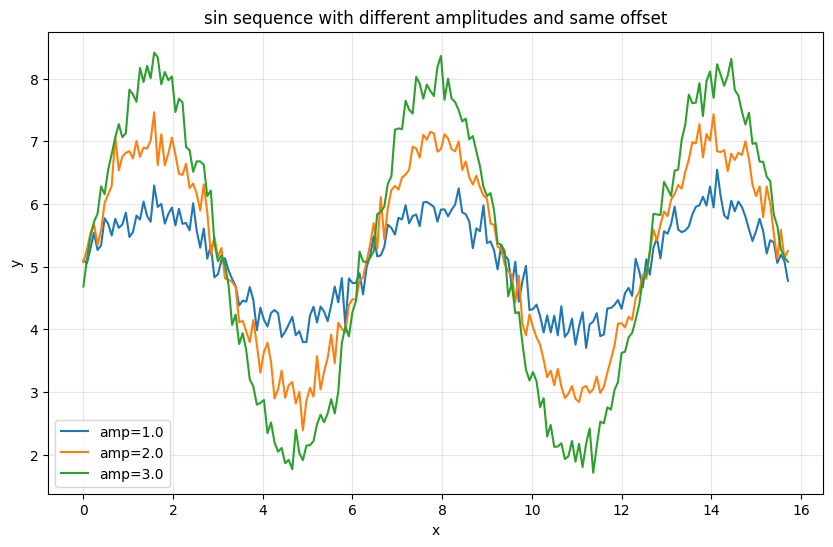

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 设置参数
np.random.seed(42)
x = np.linspace(0, 5 * np.pi, 200)
offset = 5.0
amplitudes = [1.0, 2.0, 3.0]
noise_level = 0.2

# 生成三组sin序列
y_list = []
for amp in amplitudes:
    noise = np.random.normal(0, noise_level, size=x.shape)
    y = amp * np.sin(x) + offset + noise
    y_list.append(y)

# 绘图
plt.figure(figsize=(10, 6))
for i, y in enumerate(y_list):
    plt.plot(x, y, label=f"amp={amplitudes[i]}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("sin sequence with different amplitudes and same offset")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [14]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# 取一组数据进行拟合，比如第一组
y = y_list[2]

# 定义三角函数模型，这里用正弦函数
def sin_func(x, A, w, phi, offset, tau):
    return A * np.sin(w * x + phi)*np.exp(-x/tau) + offset

# 估计初始参数
A0 = (np.max(y) - np.min(y)) / 2
w0 = 1.0
phi0 = 0
offset0 = np.mean(y)
tau0 = 0.1
p0 = [A0, w0, phi0, offset0, tau0]

# 拟合
popt, pcov = curve_fit(sin_func, x, y, p0=p0)
A_fit, w_fit, phi_fit, offset_fit, tau_fit = popt

print(f"拟合得到的振幅为: {A_fit:.3f}")
popt


拟合得到的振幅为: 3.060


array([3.05982035e+00, 1.00037128e+00, 5.45814873e-03, 4.97852461e+00,
       9.95771395e+02])

In [15]:
def sin_fitcurve(x, y):
    def sin_func(x, A, w, phi, offset):
        return A * np.sin(w * x + phi) + offset
    
    A0 = (np.max(y) - np.min(y)) / 2
    w0 = 1.0
    phi0 = 0
    offset0 = np.mean(y)
    p0 = [A0, w0, phi0, offset0]
    
    popt, pcov = curve_fit(sin_func, x, y, p0=p0)
    A_fit, w_fit, phi_fit, offset_fit = popt
    return A_fit, w_fit, phi_fit, offset_fit

sin_fitcurve(x, y)

(np.float64(3.0358202410188713),
 np.float64(1.000360721512458),
 np.float64(0.006036089332529975),
 np.float64(4.978531791842371))

In [16]:
popt

array([3.05982035e+00, 1.00037128e+00, 5.45814873e-03, 4.97852461e+00,
       9.95771395e+02])

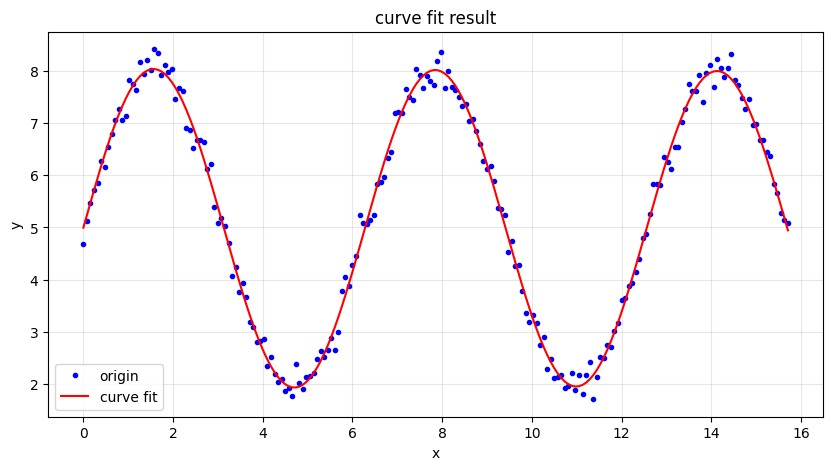

In [17]:
# 可视化拟合结果
plt.figure(figsize=(10, 5))
plt.plot(x, y, 'b.', label='origin')
plt.plot(x, sin_func(x, *popt), 'r-', label='curve fit')
plt.xlabel("x")
plt.ylabel("y")
plt.title("curve fit result")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()